# Chromatin PTR analysis
March 18, 2024

In this analysis, we determine how well individual bins correlate with gene expression.

First, the PTR values for each bin with the PTR of the gene's expression.

Second, the individual values in F for each bin with the gene expression at the deconvolved profile time. This will require some planning, because there will be many more timepoints to plot, but will be powerful once the phases of the profile timepoints are visualized in a clear way.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import glob

chrom_outdir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(chrom_outdir)


In [3]:
from cc_src.peak_to_trough_anaysis import load_deconvolved_ge_ptrs

In [6]:
ge_outdir = 'output/deconvolve_combined_g_opt_2024_03_14/gene_expression//'

ge_ptrs = load_deconvolved_ge_ptrs(ge_outdir)

In [97]:
ptr_imgs_corrected = peak_to_trough_analysis.get_strand_corrected_ptr_imgs()

In [107]:
# Compute the correlation for every single bin in the chromatin ptr 
# against the gene expression ptr
from scipy.stats import pearsonr

def compute_pearsonr_with_ge(chrom_ptr, ge_ptr):
    pearsonr_res, pval = pearsonr(chrom_ptr, ge_ptr.fillna(0))
    return pearsonr_res

flattened_corrected_ptr_imgs = ptr_imgs_corrected.reshape((ptr_imgs_corrected.shape[0], -1))

chrom_ge_pearsonrs = np.apply_along_axis(lambda chrom_col: 
    compute_pearsonr_with_ge(chrom_col, ge_ptrs.ptr), 0, flattened_corrected_ptr_imgs)


In [294]:
def plot_pearsonrs(pearson_r_res):
    plt.imshow(pearson_r_res.reshape(peak_to_trough_analysis.image_shape), origin='lower',
              cmap='RdBu_r', vmin=-0.25, vmax=0.25, aspect='auto',
              extent=[-288, 512, 0, 256])
    plt.axvline(0, c='red', alpha=0.25)
    plt.colorbar()


0

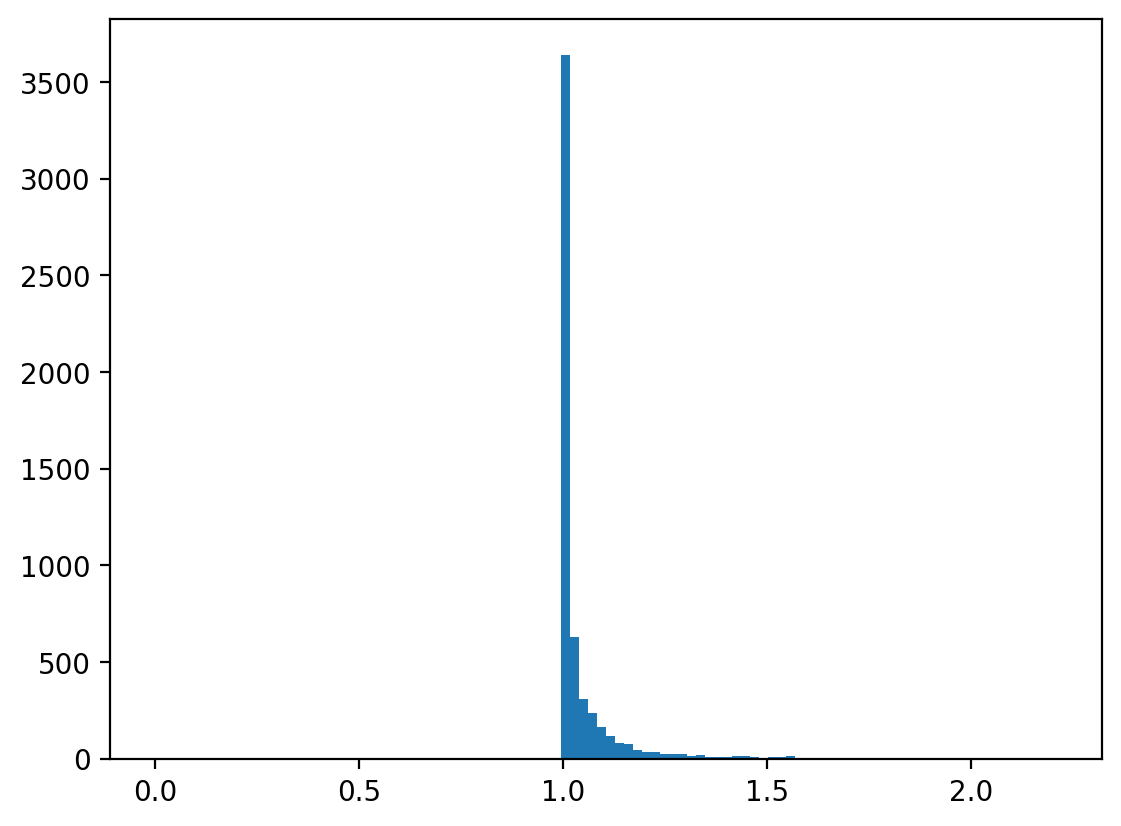

In [188]:
# The PTRs for all genes looks a bit washed out, what if we were to do the same 
# with the Spellman genes or just the Xin genes, will that give us more of a cycling
# chromatin signal?
#
# What kind of subset of genes will give us an actual PTR correlation signal
# The hope is to see some kind of pattern in the chromatin that cycles with gene expression.
#
plt.hist(ge_ptrs.ptr.fillna(0).values.flatten(), bins=100)
0

In [189]:
chrom_ge_pearsonrs.shape

(200,)

In [190]:

selected_rows = ge_ptrs.ptr > 1.25

selected_ge_ptrs = ge_ptrs[selected_rows]
selected_chrom_ptrs = flattened_corrected_ptr_imgs[selected_rows]

selected_chrom_ge_pearsonrs = np.apply_along_axis(lambda chrom_col: 
   compute_pearsonr_with_ge(chrom_col, selected_ge_ptrs.ptr), 0, selected_chrom_ptrs)



In [248]:
# Let's see what the 95th quantile looks like if we move through all the cutoffs for
# ge PTR

# Purpose: Is there a cutoff for gene expression that identifies the best threshold
# for cell cycling chromatin? What cutoff will maximize the correlation between
# the cycling chromatin and gene expression?

def threshold_ge_ptr(thresh, summary_func):
    
    # Select the gene and chromatin ptrs
    # that meet the gene expression ptr threshold
    selected_rows = ge_ptrs.ptr > thresh
    selected_ge_ptrs = ge_ptrs[selected_rows]
    selected_chrom_ptrs = flattened_corrected_ptr_imgs[selected_rows]
    selected_chrom_ge_pearsonrs = np.apply_along_axis(lambda chrom_col: 
       compute_pearsonr_with_ge(chrom_col, selected_ge_ptrs.ptr), 0, selected_chrom_ptrs)

    selected_edge_fix = selected_chrom_ge_pearsonrs.reshape(
        peak_to_trough_analysis.image_shape).copy()
    selected_edge_fix[0, :] = 0
    selected_edge_fix[-1, :] = 0
    selected_edge_fix[:, -1] = 0

    all_chrom_edge_fix = chrom_ge_pearsonrs.reshape(
        peak_to_trough_analysis.image_shape).copy()
    all_chrom_edge_fix[0, :] = 0
    all_chrom_edge_fix[-1, :] = 0
    all_chrom_edge_fix[:, -1] = 0
    
    selected_edge_fix = selected_edge_fix.flatten()
    all_chrom_edge_fix = all_chrom_edge_fix.flatten()

    n = len(selected_ge_ptrs)

    return summary_func(selected_edge_fix), summary_func(all_chrom_edge_fix), \
        selected_edge_fix, all_chrom_edge_fix, n


In [249]:
# Loop through ptr thresholds

thresholds = np.linspace(0.5, 2, 20)
means = []
ns = []

for thresh in thresholds:
    selected_mean, _, selected_edge_fix, \
        all_chrom_edge_fix = threshold_ge_ptr(thresh, summary_func=np.mean)
    means.append(selected_mean)
    ns.append(n)

Text(0.5, 1.0, 'Number of genes for per\ngene expression ptr threshold')

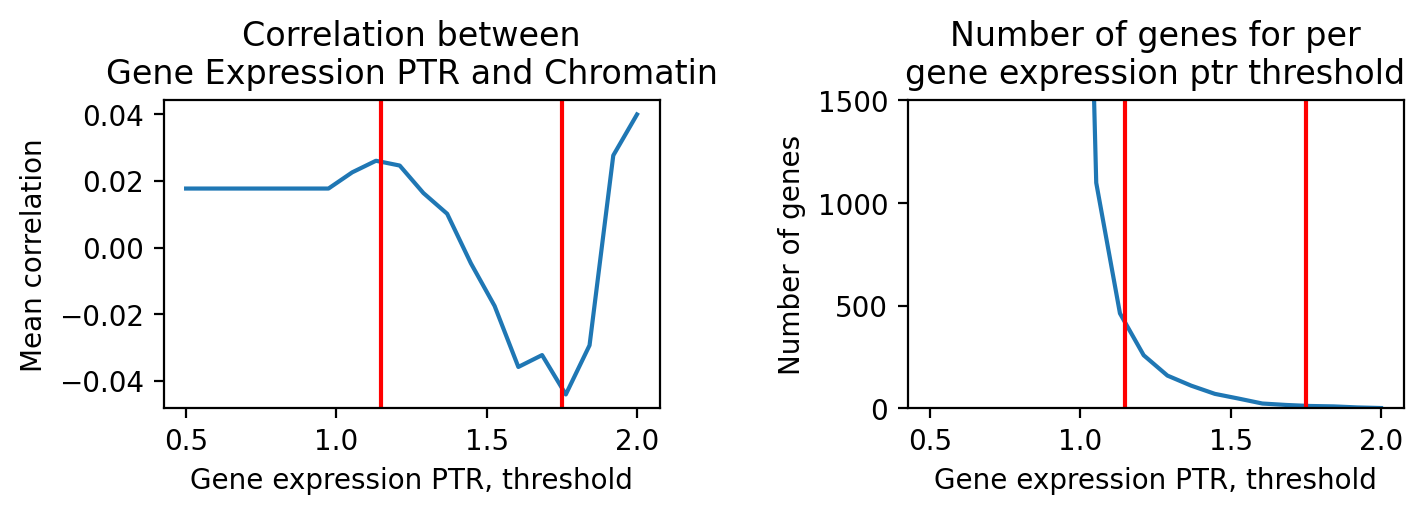

In [274]:

fig = plt.figure(figsize=(8, 2))
plt.subplots_adjust(wspace=0.5)
plt.subplot(1, 2, 1)
plt.plot(thresholds, means)
plt.xlabel("Gene expression PTR, threshold")
plt.ylabel("Mean correlation")
plt.title("Correlation between\nGene Expression PTR and Chromatin")
plt.axvline(1.15, c='red')
plt.axvline(1.75, c='red')

plt.subplot(1, 2, 2)
plt.plot(thresholds, ns)
plt.xlabel("Gene expression PTR, threshold")
plt.ylim(0, 1500)
plt.axvline(1.15, c='red')
plt.axvline(1.75, c='red')
plt.ylabel("Number of genes")
plt.title("Number of genes for per\ngene expression ptr threshold")

Text(0.5, 1.0, 'Chromatin Gene Expression Correlation\nThresh=1.75, N=12')

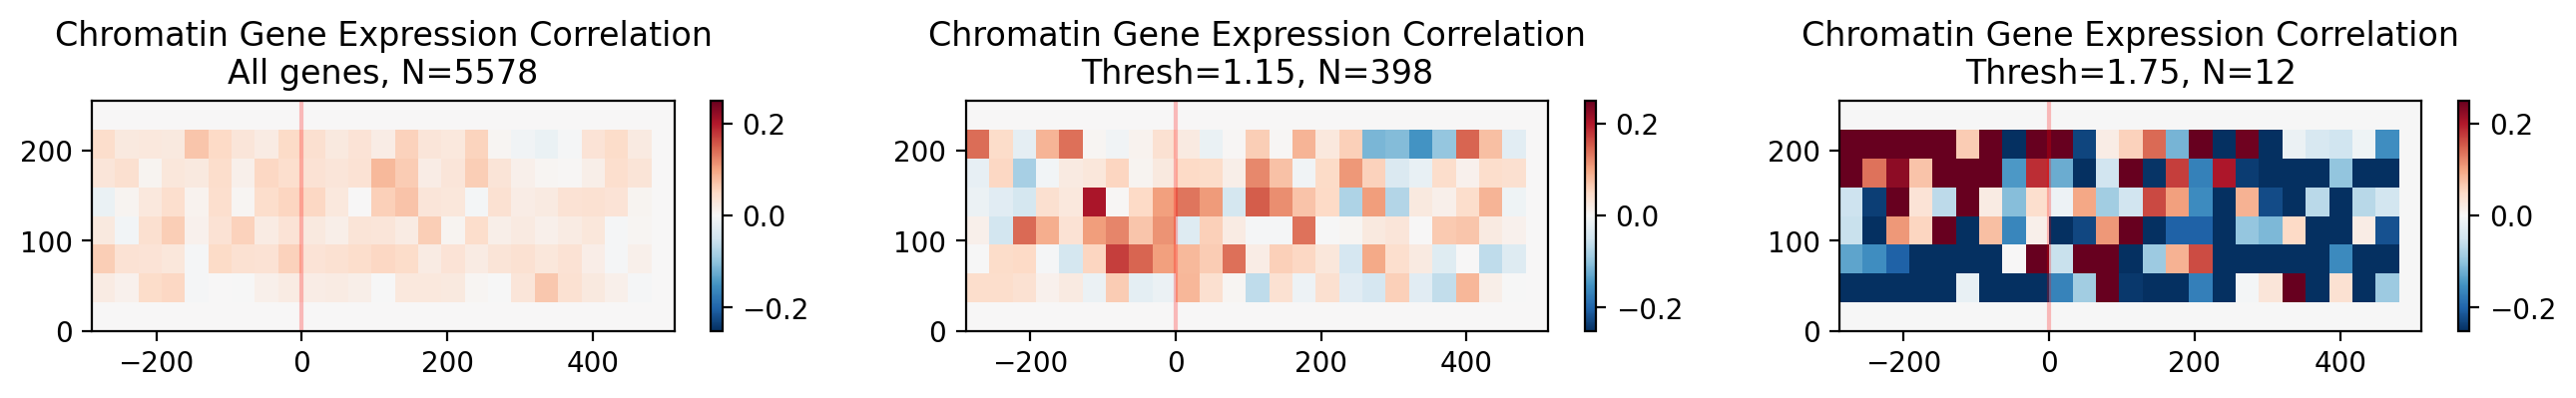

In [295]:
thresh1, thresh2 = 1.15, 1.75

_, _, selected_edge_hi_fix,\
_, ns_hi = threshold_ge_ptr(thresh1, summary_func=np.mean)

_, _, selected_edge_low_fix,\
all_chrom_edge_fix, ns_low = threshold_ge_ptr(thresh2, summary_func=np.mean)

plt.figure(figsize=(16, 1.5))
    
plt.subplot(1, 3, 1)
plot_pearsonrs(all_chrom_edge_fix)
plt.title(f"Chromatin Gene Expression Correlation\nAll genes, N={len(ge_ptrs)}")

plt.subplot(1, 3, 2)
plot_pearsonrs(selected_edge_hi_fix)
plt.title(f"Chromatin Gene Expression Correlation\nThresh={thresh1}, N={ns_hi}")

plt.subplot(1, 3, 3)
plot_pearsonrs(selected_edge_low_fix)
plt.title(f"Chromatin Gene Expression Correlation\nThresh={thresh2}, N={ns_low}")


In [ ]:
# Same analysis but for the quantile 95 measure over the mean

thresholds = np.linspace(0.5, 2, 20)
q95s = []
ns = []

def q95(dat):
    return np.quantile(dat, q=0.95)

for thresh in thresholds:
    sel_q95, _, selected_edge_fix, \
        all_chrom_edge_fix, n = threshold_ge_ptr(thresh, summary_func=q95)
    q95s.append(sel_q95)
    ns.append(n)


In [ ]:

thresh1, thresh2 = 1.15, 1.25

fig = plt.figure(figsize=(8, 2))
plt.subplots_adjust(wspace=0.5)
plt.subplot(1, 2, 1)
plt.plot(thresholds, q95s)
plt.xlabel("Gene expression PTR, threshold")
plt.ylabel("Q95 correlation")
plt.title("Correlation between\nGene Expression PTR and Chromatin")
plt.axvline(thresh1, c='red')
plt.axvline(thresh2, c='red')

plt.subplot(1, 2, 2)
plt.plot(thresholds, ns)
plt.xlabel("Gene expression PTR, threshold")
plt.ylim(0, 1500)
plt.axvline(thresh1, c='red')
plt.axvline(thresh2, c='red')
plt.ylabel("Number of genes")
plt.title("Number of genes for per\ngene expression ptr threshold")

In [ ]:


_, _, selected_edge_hi_fix,\
_, ns_hi = threshold_ge_ptr(thresh1, summary_func=q95)

_, _, selected_edge_low_fix,\
all_chrom_edge_fix, ns_low = threshold_ge_ptr(thresh2, summary_func=q95)

plt.figure(figsize=(16, 1.5))
    
plt.subplot(1, 3, 1)
plot_pearsonrs(all_chrom_edge_fix)
plt.title(f"Chromatin Gene Expression Correlation\nAll genes, N={len(ge_ptrs)}")

plt.subplot(1, 3, 2)
plot_pearsonrs(selected_edge_hi_fix)
plt.title(f"Chromatin Gene Expression Correlation\nThresh={thresh1}, N={ns_hi}")

plt.subplot(1, 3, 3)
plot_pearsonrs(selected_edge_low_fix)
plt.title(f"Chromatin Gene Expression Correlation\nThresh={thresh2}, N={ns_low}")
